In [1]:
using JLD2, LaTeXStrings, PGFPlotsX, FileIO, Plots, ColorSchemes

In [2]:
function theoretical_fidelity_limit(α)
    β = sqrt(1 - α^2)
    fidelity_limit = α^4 + β ^4
    return sqrt(fidelity_limit)
end

function single_particle_evolution_fidelity(α, γ_dephase, t)
    β = sqrt(1-α^2)
    fidelity = α^4 + β^4 + (2 * α^2 * β^2 * (exp(-γ_dephase*t)) )
    return sqrt(fidelity)
end

single_particle_evolution_fidelity (generic function with 1 method)

In [5]:
@load "/Users/akashmalemath/Documents/master_work/rydberg_thesis/new_10k_traj_files/N_atoms=5_γ_dephase=1.0e-5_case1_phase=0.915_Ntraj=10000_avg_s1.jld2"
e1 = avg_fidelity_after_encoding   
s1 = avg_fidelity_after_storage
c1 = avg_fidelity_after_correction


@load "/Users/akashmalemath/Documents/master_work/rydberg_thesis/new_10k_traj_files/N_atoms=5_γ_dephase=1.0e-5_case1_phase=0.915_Ntraj=10000_avg_s10.jld2"
e10 = avg_fidelity_after_encoding   
s10 = avg_fidelity_after_storage
c10 = avg_fidelity_after_correction


@load "/Users/akashmalemath/Documents/master_work/rydberg_thesis/new_10k_traj_files/N_atoms=5_γ_dephase=1.0e-5_case1_phase=0.915_Ntraj=10000_avg_s20.jld2"
e20 = avg_fidelity_after_encoding   
s20 = avg_fidelity_after_storage
c20 = avg_fidelity_after_correction

@load "/Users/akashmalemath/Documents/master_work/rydberg_thesis/new_10k_traj_files/N_atoms=5_γ_dephase=1.0e-5_case1_phase=0.915_Ntraj=10000_avg_s30.jld2"
e30 = avg_fidelity_after_encoding   
s30 = avg_fidelity_after_storage
c30 = avg_fidelity_after_correction


@load "/Users/akashmalemath/Documents/master_work/rydberg_thesis/new_10k_traj_files/N_atoms=5_γ_dephase=1.0e-5_case1_phase=0.915_Ntraj=10000_avg_s40.jld2"
e40 = avg_fidelity_after_encoding   
s40 = avg_fidelity_after_storage
c40 = avg_fidelity_after_correction

@load "/Users/akashmalemath/Documents/master_work/rydberg_thesis/new_10k_traj_files/N_atoms=5_γ_dephase=1.0e-5_case1_phase=0.915_Ntraj=10000_avg_s50.jld2"
e50 = avg_fidelity_after_encoding   
s50 = avg_fidelity_after_storage
c50 = avg_fidelity_after_correction;

e_s = [e1, e10, e20, e30, e40, e50]
s_s = [s1, s10, s20, s30, s40, s50]
c_s = [c1, c10, c20, c30, c40, c50];


In [6]:
idx = [1,10,20,30,40,50]
single_particle = zeros(Float64, length(idx))
for i in 1:length(idx)
    single_particle[i] = single_particle_evolution_fidelity(sqrt(1/5),1.0e-5,(idx[i]+1)*268)
end

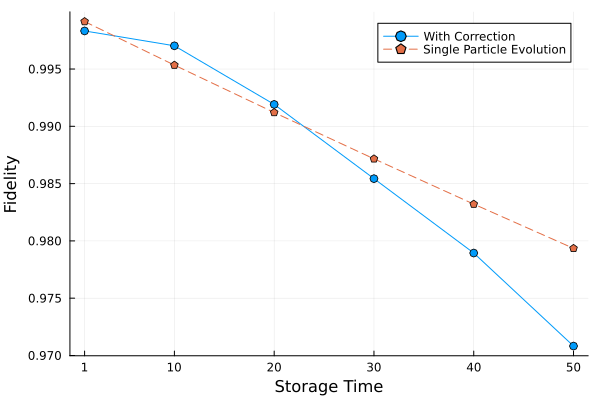

In [8]:
# plot(idx, e_s, label="Encoding", marker=:o)
# plot!(idx, s_s, label="Storage", marker=:o)
plot(idx, c_s, xticks=idx, label="With Correction", marker=:o, 
            ylabel="Fidelity", xlabel="Storage Time", grid=true)
plot!(idx, single_particle, label="Single Particle Evolution", marker=:p, linestyle=:dash)